### DANE I PREPROCESSING

In [1]:
#=================
# 1. PREPROCESSING
#=================

import pandas as pd
import duckdb as db
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import gc
import os
import re
import warnings
import xgboost as xgb 
from xgboost import XGBClassifier
from xgboost import callback
from sklearn.model_selection import RandomizedSearchCV, StratifiedShuffleSplit
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix, roc_curve,
    precision_recall_curve, PrecisionRecallDisplay, average_precision_score
)
from sklearn.inspection import permutation_importance
from scipy.stats import uniform, randint

def cleanup(*objs):
    """Usuwa wskazane obiekty i czyści RAM"""
    for obj in objs:
        try:
            del obj
        except Exception:
            pass
    plt.close("all")
    gc.collect()


warnings.filterwarnings("ignore")

# Ścieżki
data_path = ""
output_dir = os.path.join(data_path, "Wyniki_XGBoost")
os.makedirs(output_dir, exist_ok=True)

# Dane
train = pd.read_parquet(f"{data_path}/final_base_xgb_train.parquet")
test  = pd.read_parquet(f"{data_path}/final_base_xgb_test.parquet")

X_train = train.drop(columns=["default_flag", "postal_code"], errors="ignore")
y_train = train["default_flag"].astype(int)
X_test  = test.drop(columns=["default_flag", "postal_code"], errors="ignore")
y_test  = test["default_flag"].astype(int)

# Przekształcenia dat
def yyyymm_to_date(val):
    try:
        val = int(val)
        return pd.Timestamp(year=val // 100, month=val % 100, day=1)
    except Exception:
        return pd.NaT

for df in [X_train, X_test]:
    if "first_payment_date" in df.columns:
        dt = df["first_payment_date"].apply(yyyymm_to_date)
        df["first_payment_year"] = dt.dt.year
        df.drop(columns=["first_payment_date"], inplace=True, errors="ignore")

# Number_of_borrowers jako liczba
for df in [X_train, X_test]:
    if "number_of_borrowers" in df.columns:
        df["number_of_borrowers"] = pd.to_numeric(df["number_of_borrowers"], errors="coerce")

# Kodowanie (Y/N -> 0/1, OHE reszty; drop wysokiej krotności
high_card_cols = [c for c in X_train.columns
                  if X_train[c].dtype == "object" and X_train[c].nunique(dropna=True) > 100]
X_train.drop(columns=high_card_cols, inplace=True, errors="ignore")
X_test.drop(columns=[c for c in high_card_cols if c in X_test.columns], inplace=True, errors="ignore")

def map_binary_yn(df):
    for c in df.select_dtypes(include="object").columns:
        vals = set(df[c].dropna().unique())
        if vals <= {"Y", "N"}:
            df[c] = df[c].map({"Y": 1, "N": 0})
    return df

X_train = map_binary_yn(X_train)
X_test  = map_binary_yn(X_test)
X_train = pd.get_dummies(X_train, drop_first=True)
X_test  = pd.get_dummies(X_test,  drop_first=True)
X_test  = X_test.reindex(columns=X_train.columns, fill_value=0)
feature_names = X_train.columns.tolist()

assert "first_payment_year" in X_train.columns and "first_payment_year" in X_test.columns

# Balans klas i GPU
pos = int(y_train.sum())
neg = int((y_train == 0).sum())
scale_pos_weight = neg / max(pos, 1)

USE_GPU = False
TREE_METHOD = "gpu_hist" if USE_GPU else "hist"

### TUNING

In [2]:
#==========
# 2. TUNING
#==========
import json
from sklearn.model_selection import RandomizedSearchCV

# Estymator bazowy
xgb_base = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    tree_method="hist",
    random_state=42,
    scale_pos_weight=scale_pos_weight,
    n_jobs=4 
)

# Siatka parametrów
param_dist = {
    "n_estimators": [300, 600, 1000],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "min_child_weight": [1, 5, 10],
    "reg_lambda": [1, 5]
}

# Ograniczenie próby dla tuningu
TUNE_SAMPLE = 200_000
if len(X_train) > TUNE_SAMPLE:
    train_idx = np.random.RandomState(42).choice(X_train.index, size=TUNE_SAMPLE, replace=False)
    X_train_tune = X_train.loc[train_idx]
    y_train_tune = y_train.loc[train_idx]
else:
    X_train_tune = X_train
    y_train_tune = y_train

print(f"Tuning na {len(X_train_tune):,} rekordach...")

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    scoring="roc_auc",
    verbose=2,
    random_state=42,
    n_jobs=1
)

random_search.fit(X_train_tune, y_train_tune)
print("BEST PARAMS (CV):", random_search.best_params_)

# Zapis najlepszych parametrów do pliku
best_params_path = os.path.join(output_dir, "best_params_xgb.json")
with open(best_params_path, "w") as f:
    json.dump(random_search.best_params_, f)

cleanup(random_search, X_train_tune, y_train_tune)

Tuning na 200,000 rekordach...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=7, min_child_weight=5, n_estimators=1000, reg_lambda=5, subsample=1.0; total time=  16.0s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=7, min_child_weight=5, n_estimators=1000, reg_lambda=5, subsample=1.0; total time=  15.8s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=7, min_child_weight=5, n_estimators=1000, reg_lambda=5, subsample=1.0; total time=  15.5s
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=3, min_child_weight=1, n_estimators=600, reg_lambda=1, subsample=0.8; total time=   7.7s
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=3, min_child_weight=1, n_estimators=600, reg_lambda=1, subsample=0.8; total time=   7.9s
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=3, min_child_weight=1, n_estimators=600, reg_lambda=1, subsample=0.8; total time=   7.5s
[CV] END co

### FINALNY MODEL

In [2]:
# ================
# 3. FINALNY MODEL
# ================
import json
import shap
import os
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

# Wczytanie parametrów z tuningu
best_params_path = os.path.join(output_dir, "best_params_xgb.json")
with open(best_params_path, "r") as f:
    best_params = json.load(f)

# Wybór próby stratyfikowanej
REFIT_SAMPLE = 5_000_000
if len(X_train) > REFIT_SAMPLE:
    X_refit, _, y_refit, _ = train_test_split(
        X_train, y_train,
        train_size=REFIT_SAMPLE,
        stratify=y_train,
        random_state=42
    )
else:
    X_refit, y_refit = X_train, y_train

print(f"Refit XGBoost na {len(X_refit):,} rekordach...")

# Finalny model
clf_best = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    tree_method="hist",   
    random_state=42,
    scale_pos_weight=scale_pos_weight,
    n_jobs=4,
    **best_params   # Parametry z tuningu
)

# Dopasowanie na próbie
clf_best.fit(X_refit, y_refit, verbose=50)

# =========
# PREDYKCJE
# =========
y_proba = clf_best.predict_proba(X_test)[:, 1]
y_pred  = (y_proba > 0.5).astype(int)

X_test["y_proba"] = y_proba
X_test["y_pred"]  = y_pred
X_test["y_true"]  = y_test.values

print("AUC (test):", roc_auc_score(y_test, y_proba))

# Zapis modelu
model_path = os.path.join(output_dir, "xgb_model_final.pkl")
joblib.dump(clf_best, model_path)
print(f"Model zapisany do: {model_path}")

# Zapis testu z predykcjami
test_with_preds_path = os.path.join(output_dir, "xgb_test_with_preds.parquet")
X_test.to_parquet(test_with_preds_path, index=False)
print(f"Test z predykcjami zapisany do: {test_with_preds_path}")

# Zapis feature_names
feature_names = X_train.columns.tolist()
features_path = os.path.join(output_dir, "xgb_feature_names.npy")
np.save(features_path, np.array(feature_names))
print(f"Feature names zapisane do: {features_path}")

# =======================
# SHAP – liczenie i zapis
# =======================
# Próbka do SHAP
X_sample = X_refit.sample(n=min(500_000, len(X_refit)), random_state=42)

explainer = shap.TreeExplainer(clf_best)
shap_values = explainer(X_sample)

# Zapis shap_values i base_values
np.save(os.path.join(output_dir, "shap_values.npy"), shap_values.values)
np.save(os.path.join(output_dir, "shap_base_values.npy"), shap_values.base_values)

# Zapis próby cech
X_sample.to_parquet(os.path.join(output_dir, "shap_sample.parquet"))

# Ranking globalny
importances = np.abs(shap_values.values).mean(axis=0)
importances_series = pd.Series(importances, index=X_sample.columns).sort_values(ascending=False)
importances_series.to_csv(os.path.join(output_dir, "shap_importances.csv"))

# Listy top5, TOP_CONT, TOP_CAT
top5 = importances_series.head(5).index.tolist()

def _is_dummy01(s: pd.Series) -> bool:
    u = pd.Series(s.dropna().unique())
    return (len(u) > 0) and u.isin([0, 1]).all()

_EXCLUDE_NAME_TOKENS = ["msa","zip","postal","code","id","year","month","date","day","days_since","number_of_borrowers"]
_EXCLUDE_EXACT = {"first_payment_year"}

def _is_name_excluded(name: str) -> bool:
    n = str(name).lower()
    if n in _EXCLUDE_EXACT: return True
    return any(tok in n for tok in _EXCLUDE_NAME_TOKENS)

SAFE_CAT_FEATURES = [c for c in X_sample.columns if not _is_name_excluded(c) and _is_dummy01(X_sample[c])]
SAFE_CONT_FEATURES = [
    c for c in X_sample.columns
    if not _is_name_excluded(c)
    and pd.api.types.is_numeric_dtype(X_sample[c])
    and not _is_dummy01(X_sample[c])
    and X_sample[c].nunique(dropna=True) >= 3
]

TOP_ALL  = [c for c in top5 if c in X_sample.columns]
TOP_CONT = [c for c in TOP_ALL if c in SAFE_CONT_FEATURES]
TOP_CAT  = [c for c in TOP_ALL if c in SAFE_CAT_FEATURES]

# Zapis list
pd.Series(top5).to_csv(os.path.join(output_dir, "shap_top5.csv"), index=False)
pd.Series(TOP_CONT).to_csv(os.path.join(output_dir, "shap_top_cont.csv"), index=False)
pd.Series(TOP_CAT).to_csv(os.path.join(output_dir, "shap_top_cat.csv"), index=False)

print("SHAP + listy cech zapisane.")

Refit XGBoost na 5,000,000 rekordach...
AUC (test): 0.8552120250850366
Model zapisany do: C:/Users/khtur/Desktop/Praca magisterska/Dane/Dane_do_modelu/Analiza\Wyniki_XGBoost\xgb_model_final.pkl
Test z predykcjami zapisany do: C:/Users/khtur/Desktop/Praca magisterska/Dane/Dane_do_modelu/Analiza\Wyniki_XGBoost\xgb_test_with_preds.parquet
Feature names zapisane do: C:/Users/khtur/Desktop/Praca magisterska/Dane/Dane_do_modelu/Analiza\Wyniki_XGBoost\xgb_feature_names.npy
SHAP + listy cech zapisane.


### ANALIZY

Model wczytany: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=5, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=600,
              n_jobs=4, num_parallel_tree=None, ...)
Model wczytany: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enab

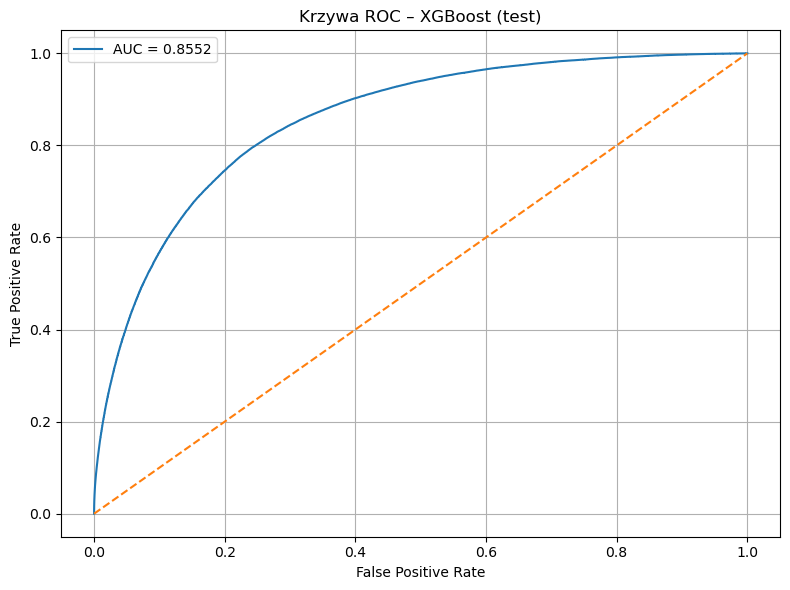

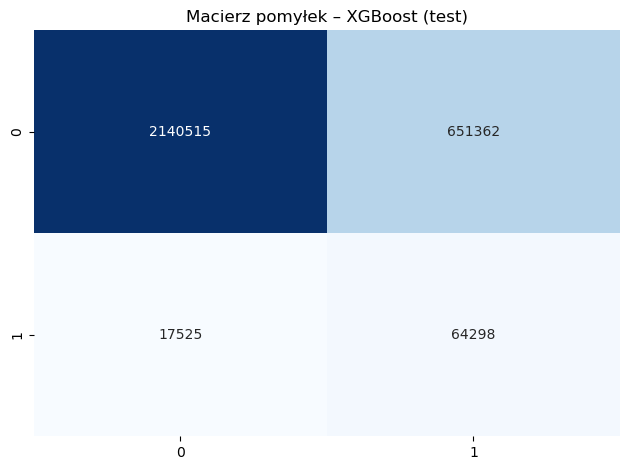

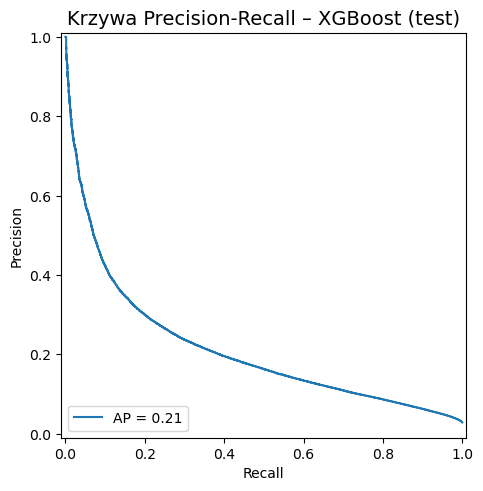

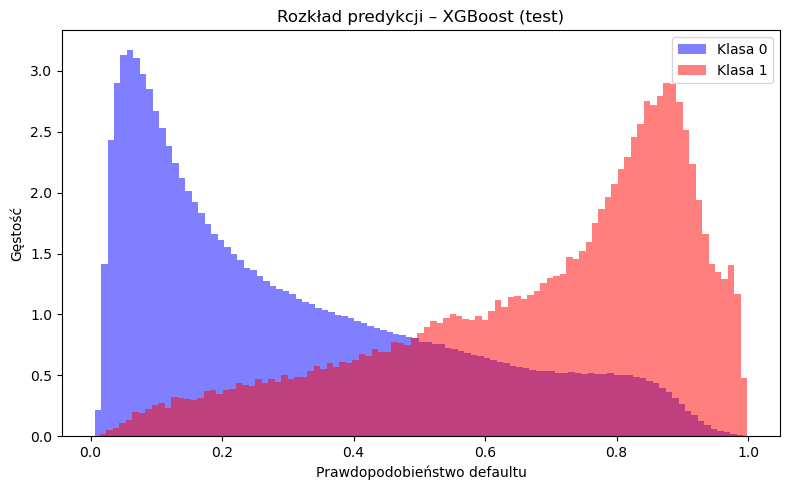

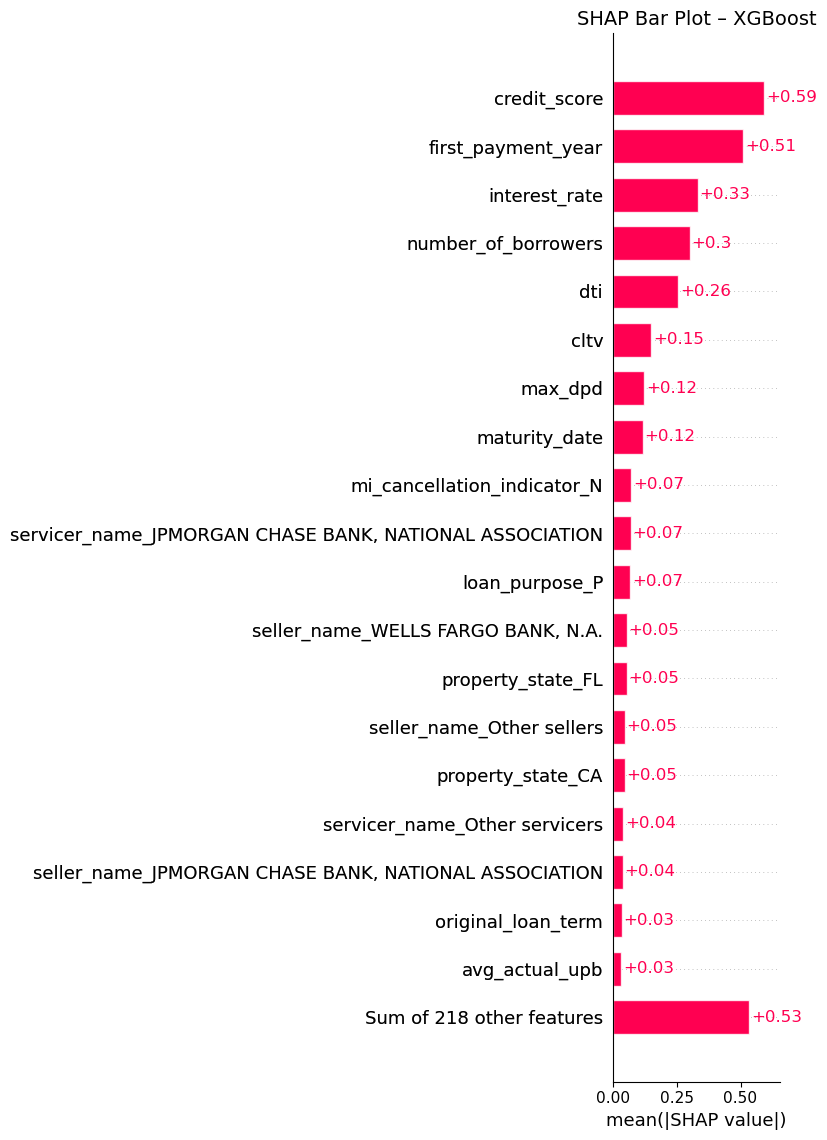

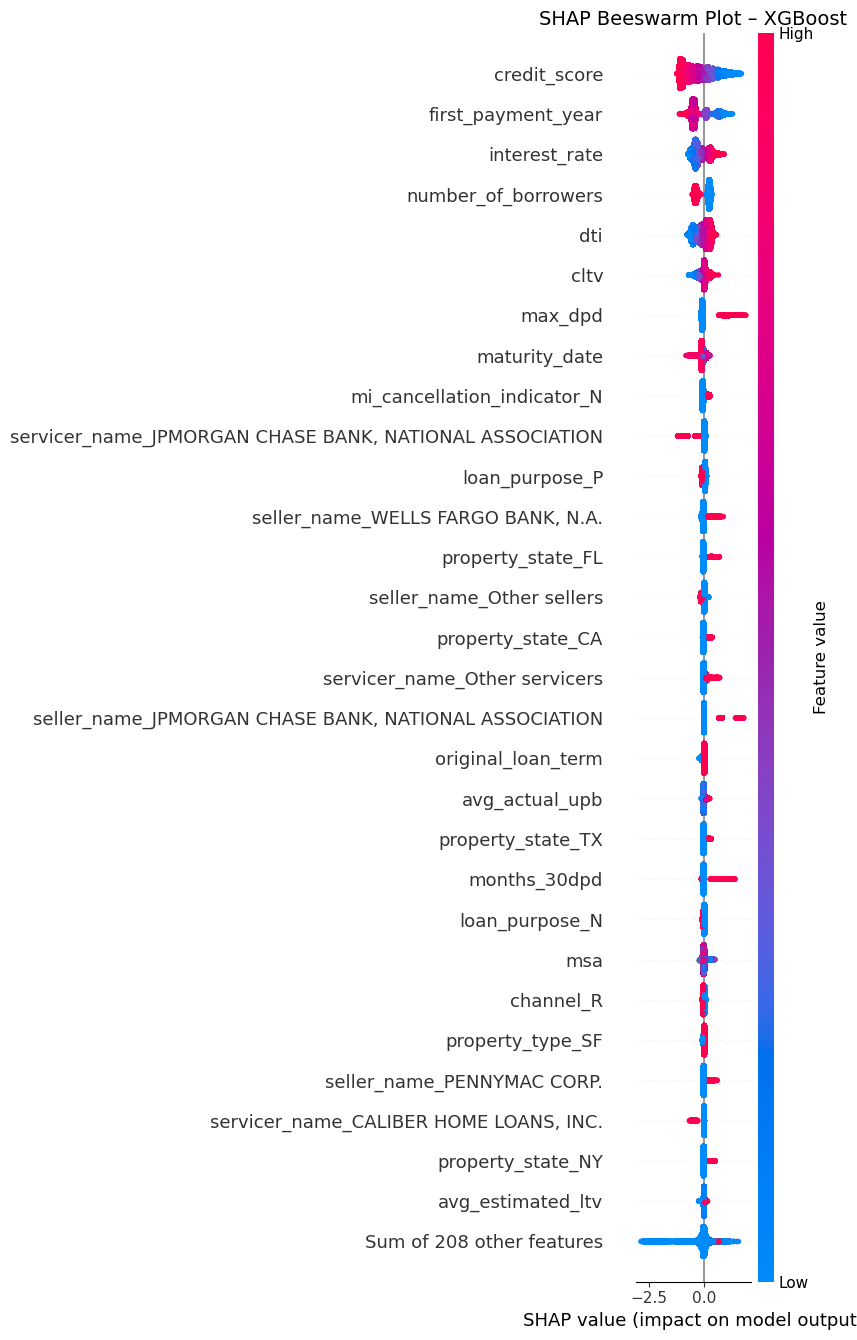

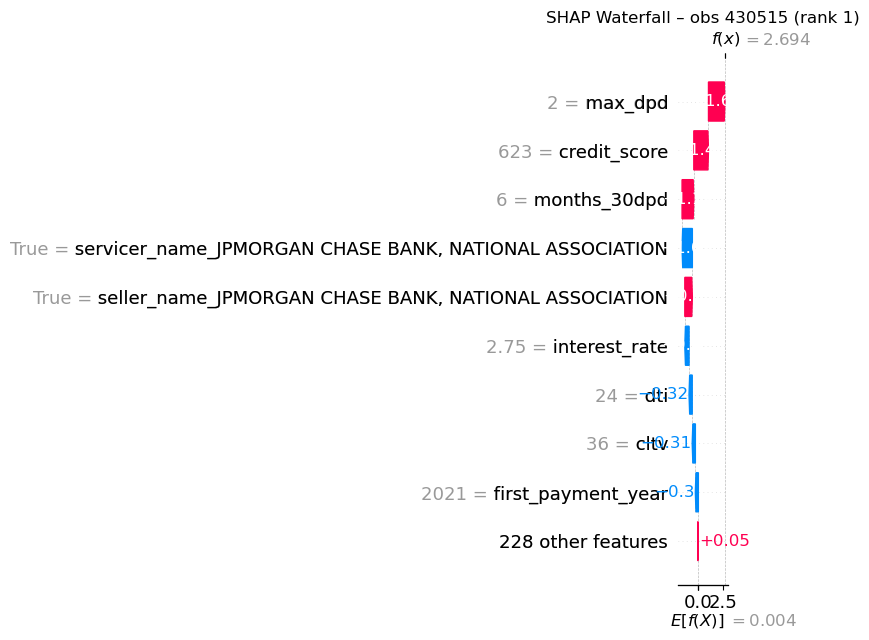

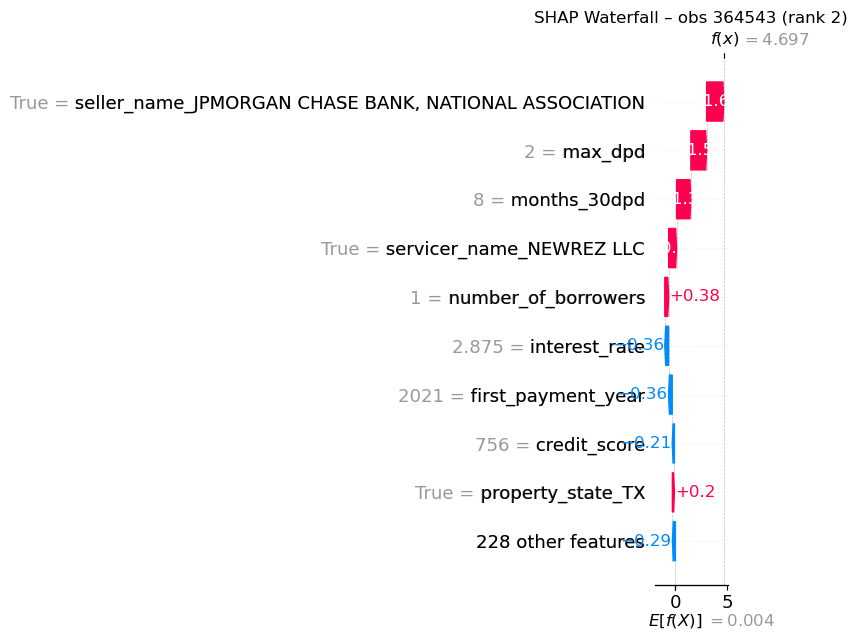

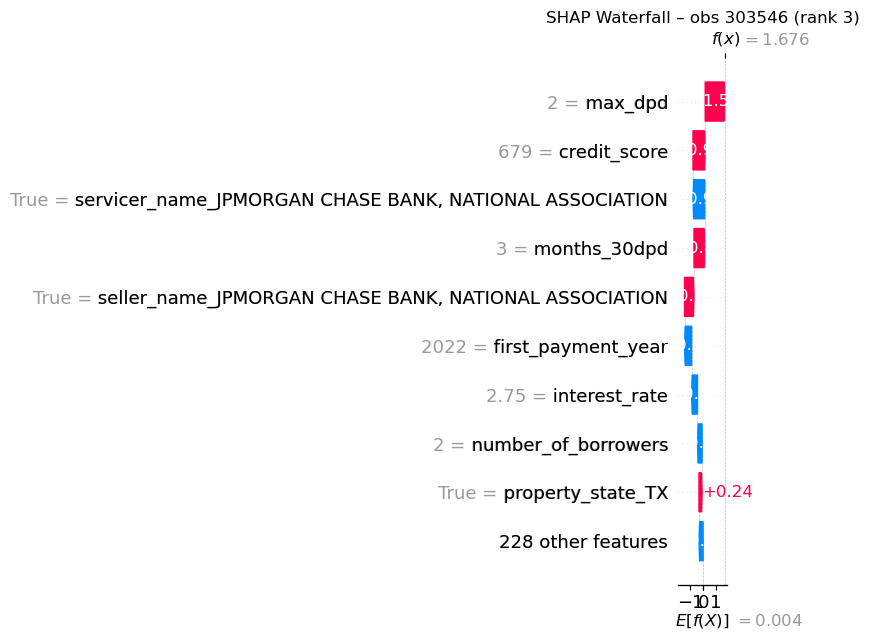

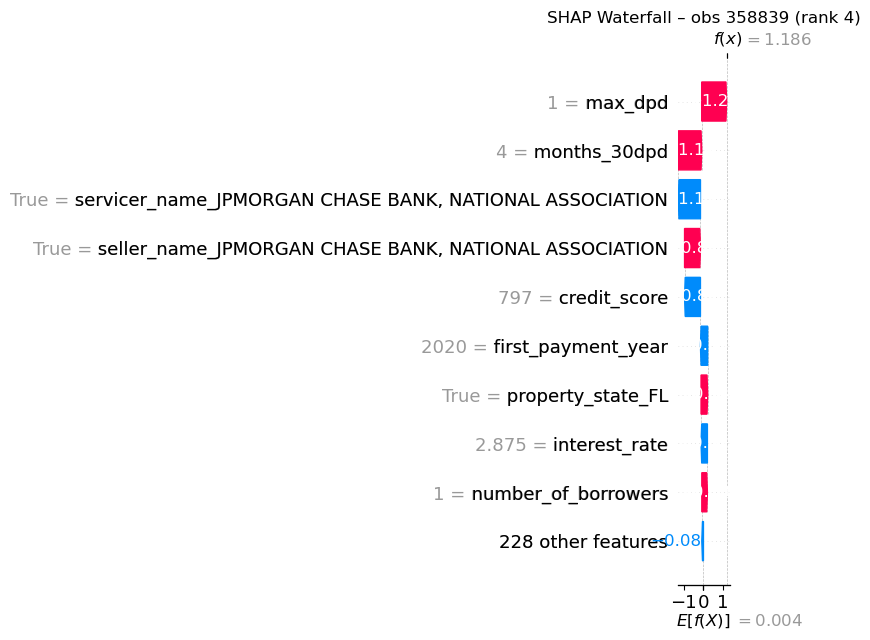

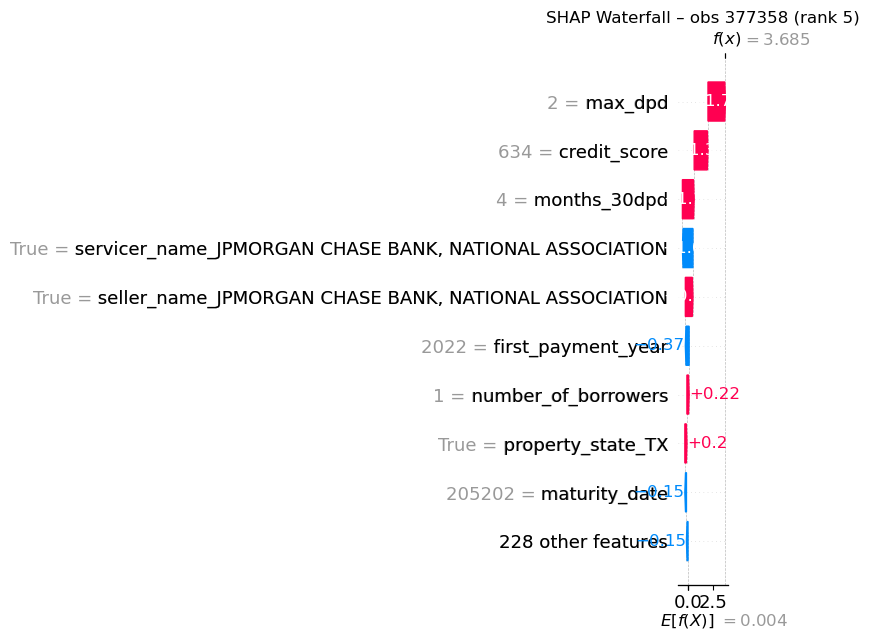

Zapisano force plot HTML: shap_force_obs430515_xgb.html


<Figure size 640x480 with 0 Axes>

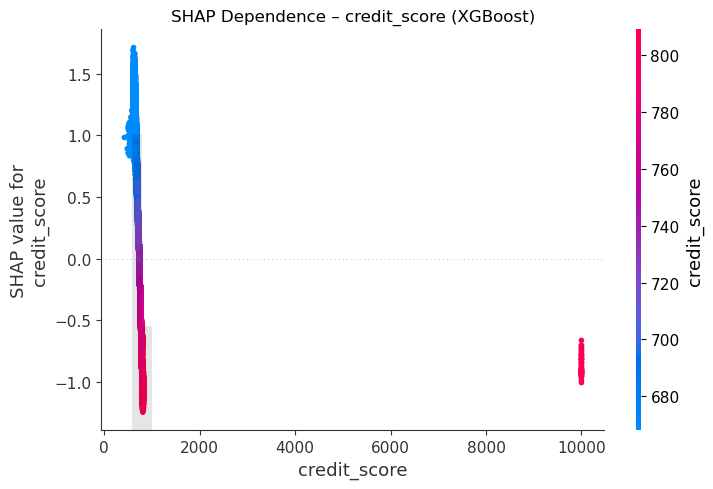

<Figure size 640x480 with 0 Axes>

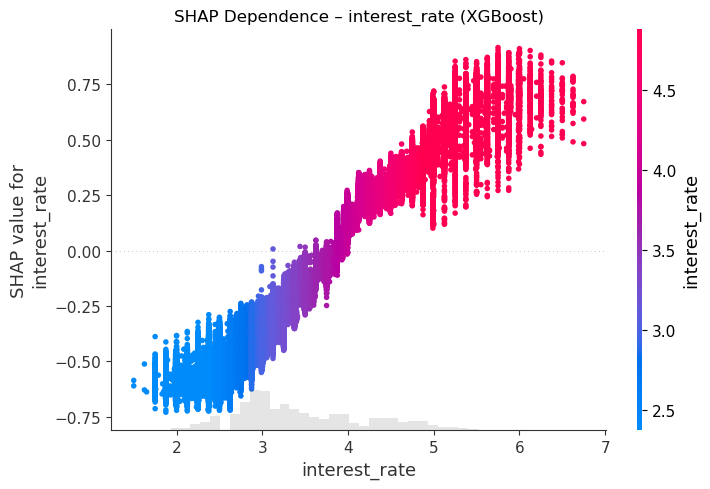

<Figure size 640x480 with 0 Axes>

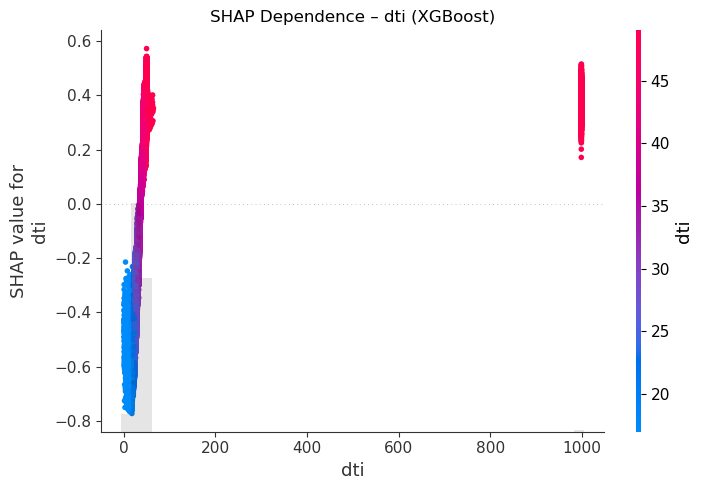

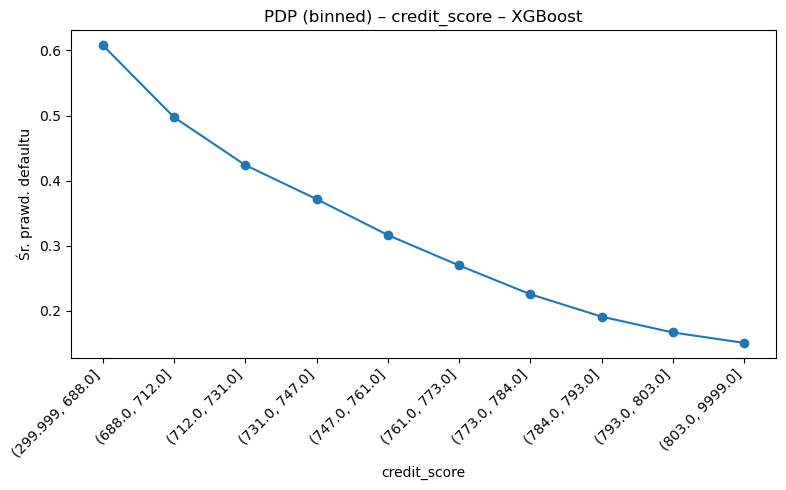

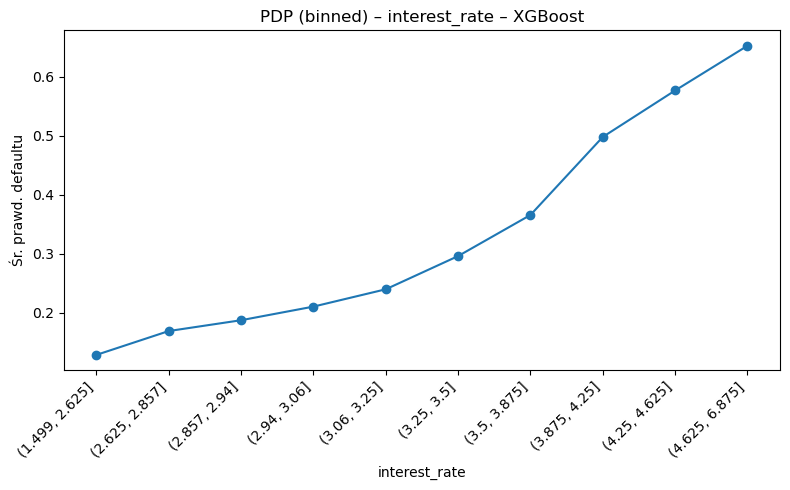

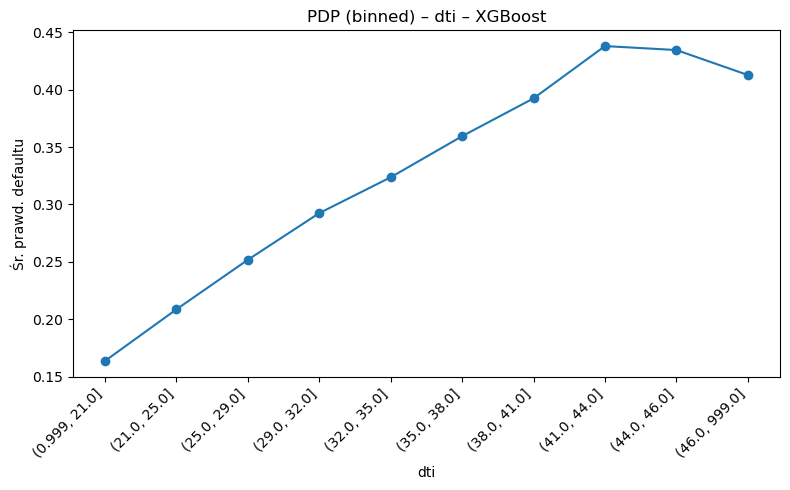

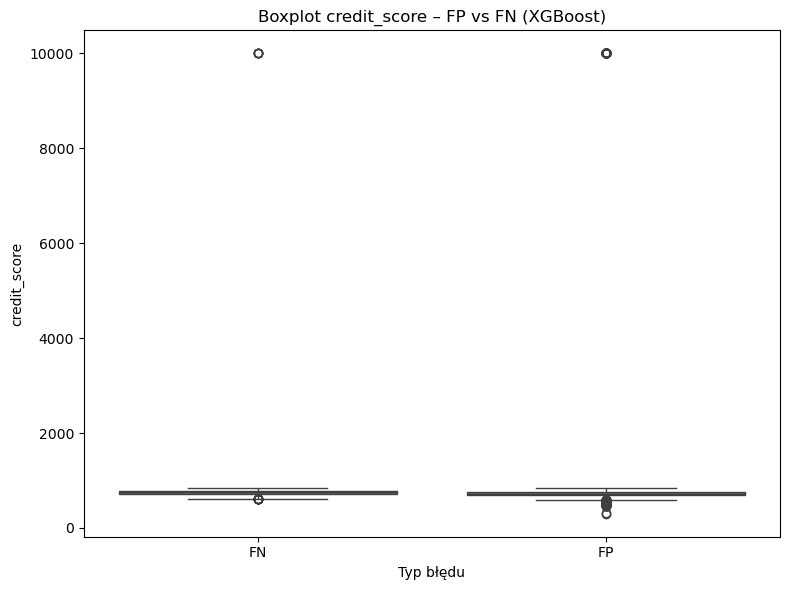

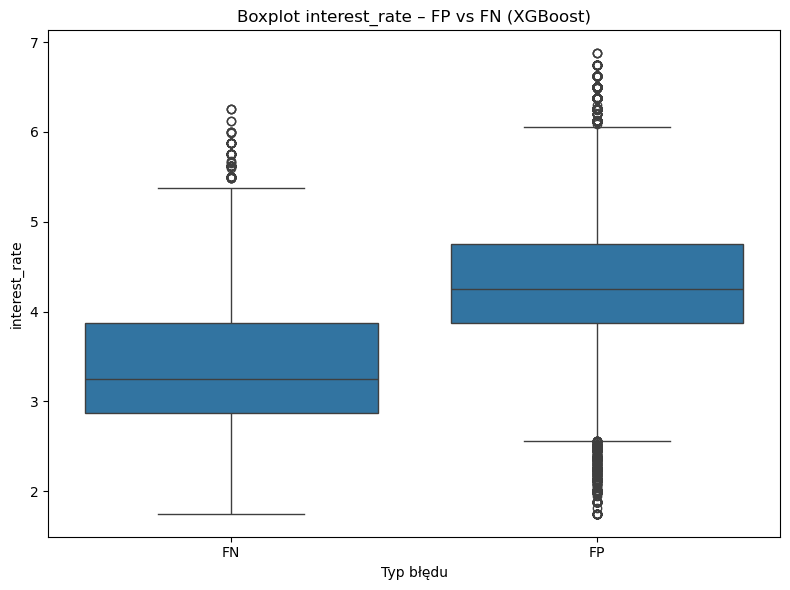

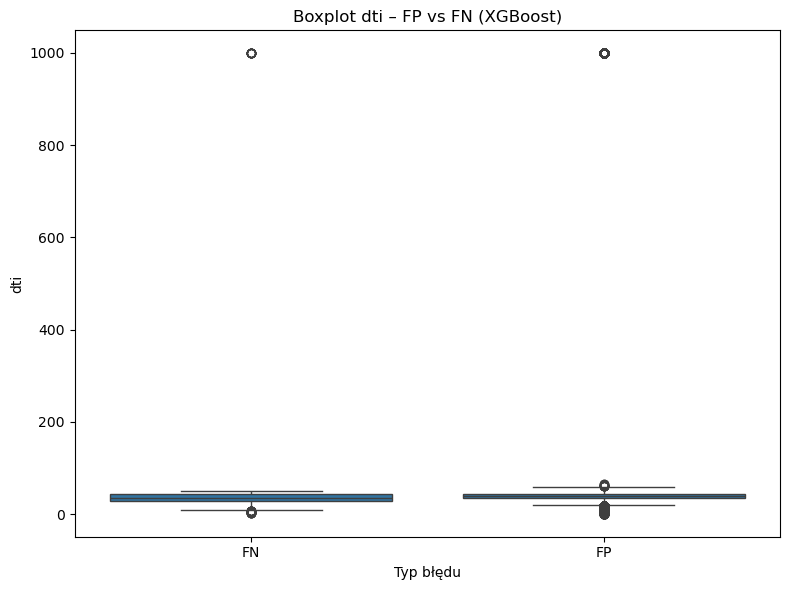

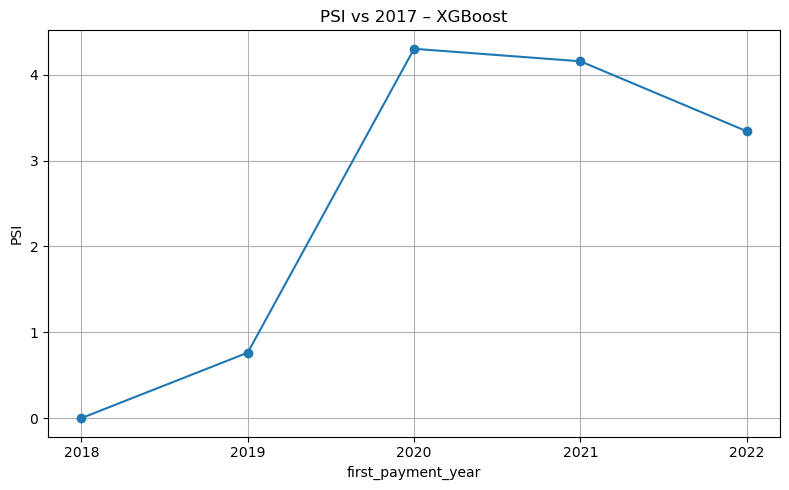

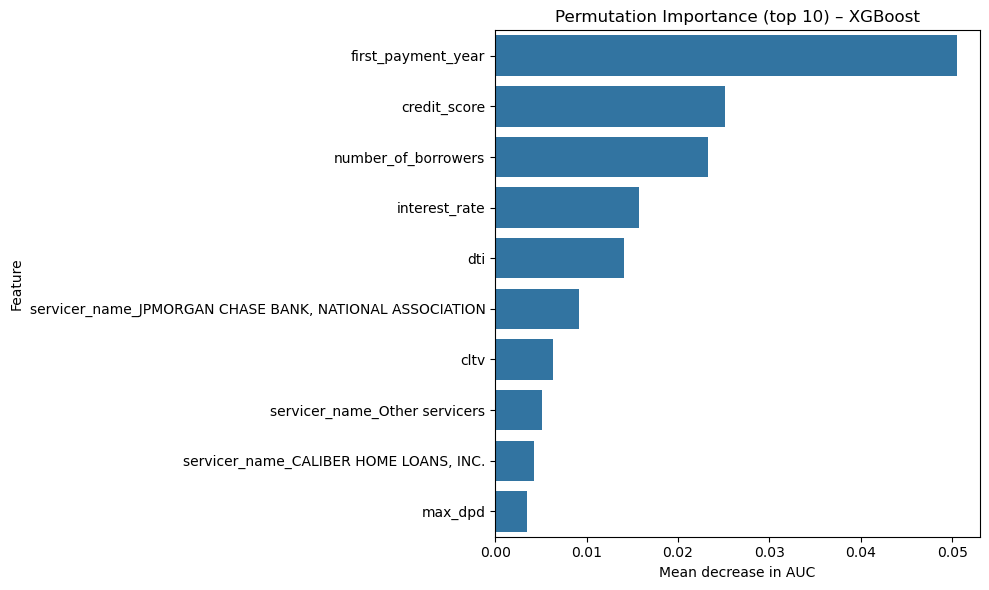

Perturbacja – TOP_CONT (XGBoost)
Perturbacja — cechy: ['credit_score', 'interest_rate', 'dti']


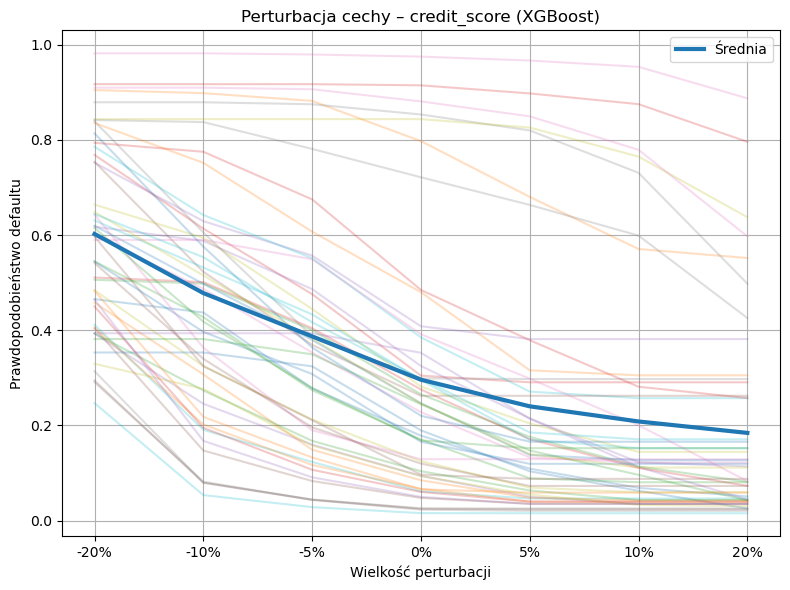

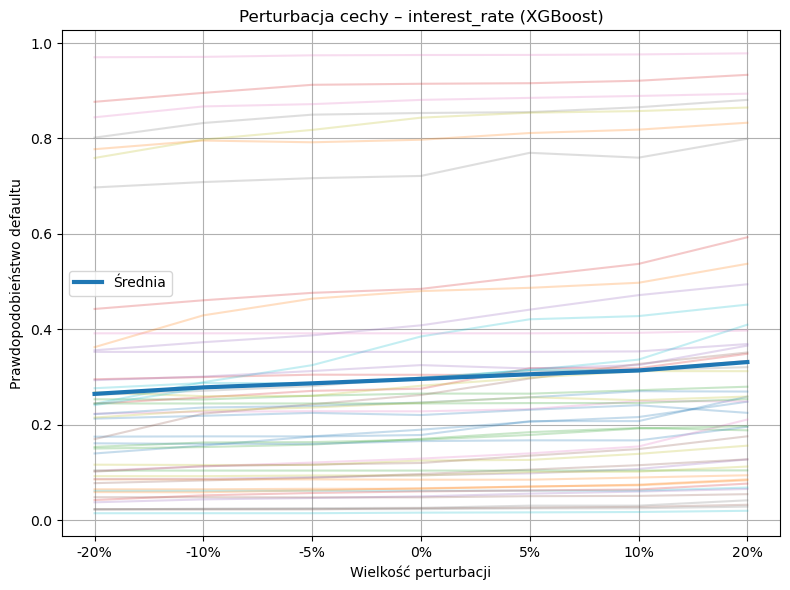

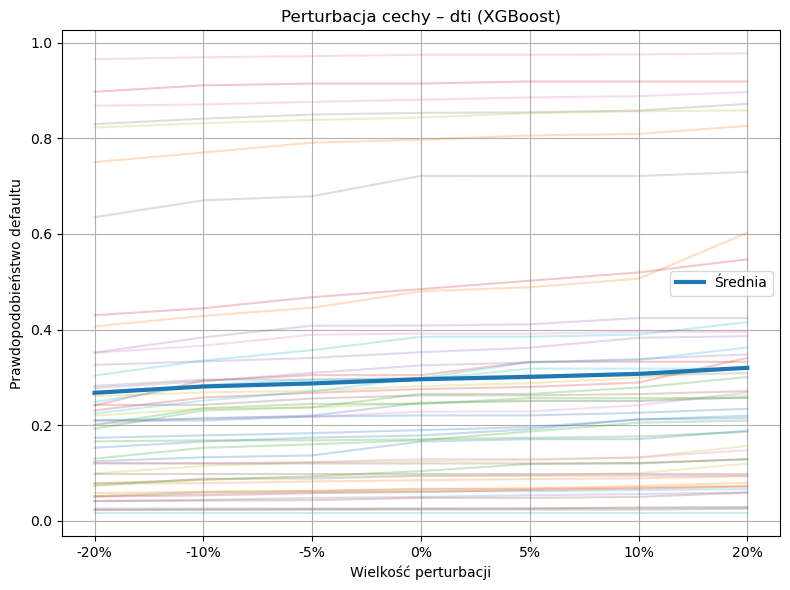

Zapisano: feature_perturbation_summary_xgb.csv


<Figure size 800x600 with 0 Axes>

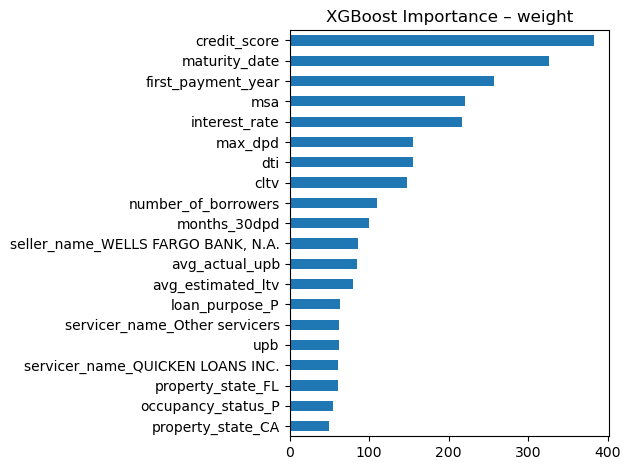

<Figure size 800x600 with 0 Axes>

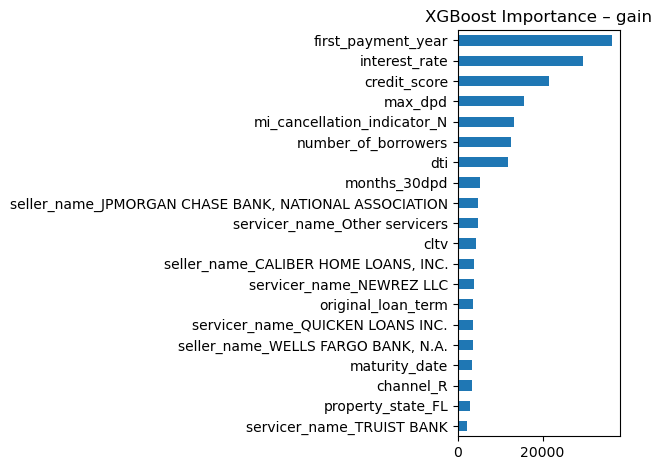

<Figure size 800x600 with 0 Axes>

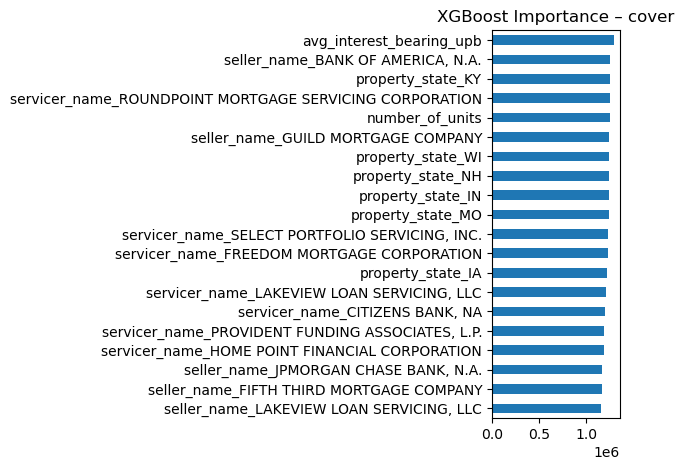

<Figure size 800x600 with 0 Axes>

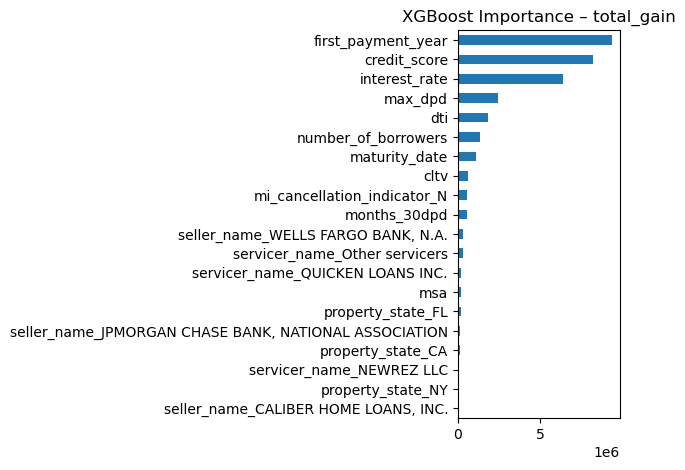

<Figure size 800x600 with 0 Axes>

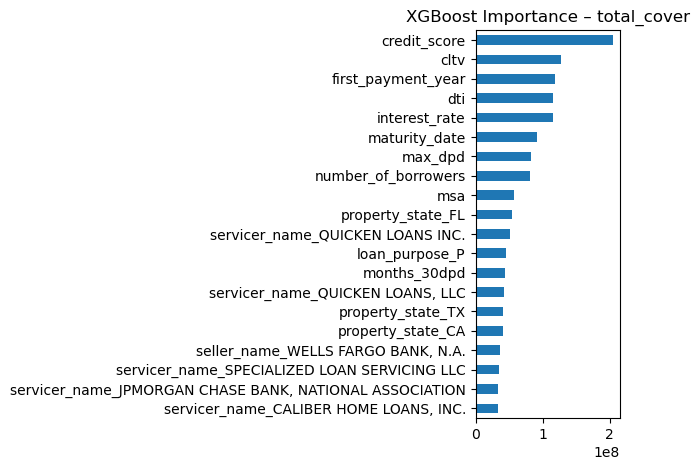

CSI (Top5 CONT): bazowy rok vs bieżące dane – XGBoost


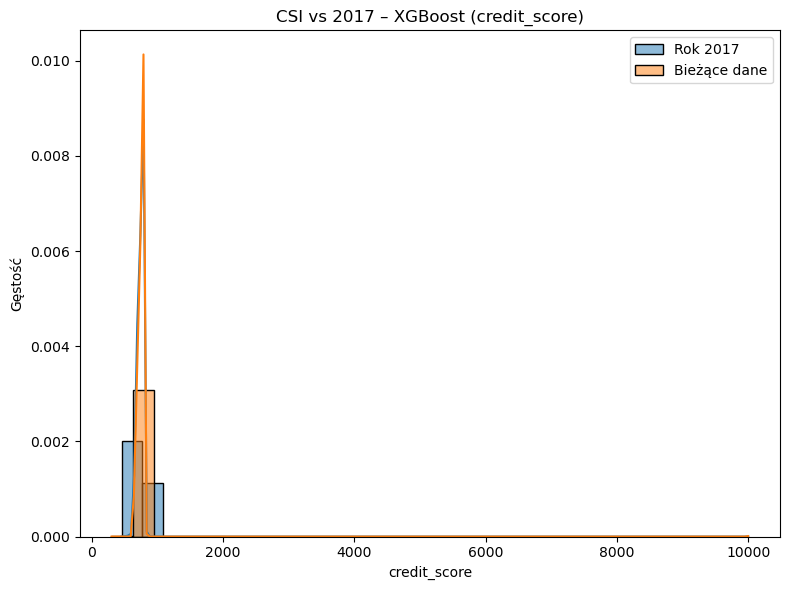

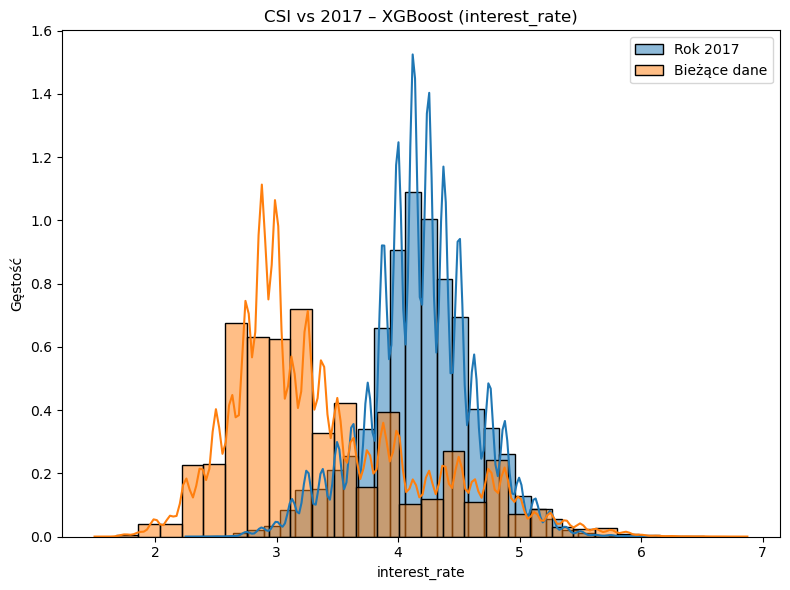

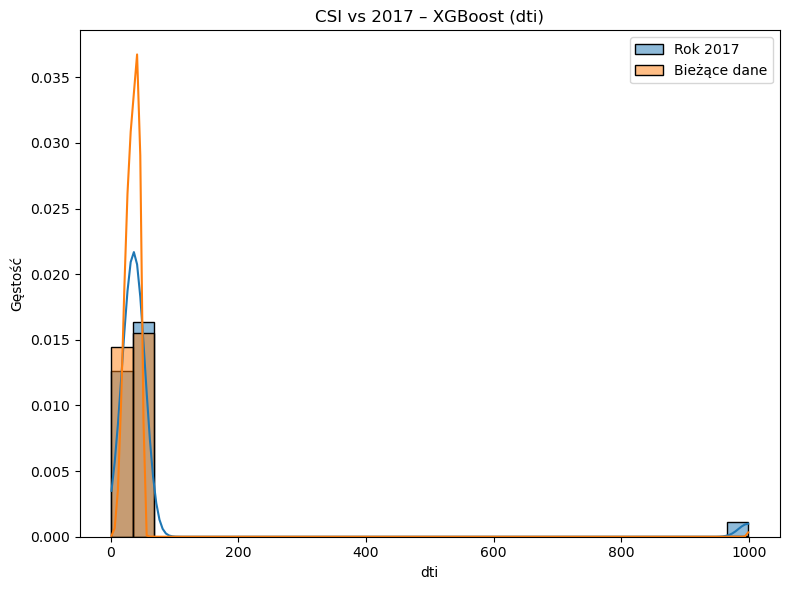

CSI zapisane do: C:/Users/khtur/Desktop/Praca magisterska/Dane/Dane_do_modelu/Analiza\Wyniki_XGBoost/csi_xgb_top5_summary.csv
AUC per year – TOP_CONT i TOP_CAT (XGBoost)


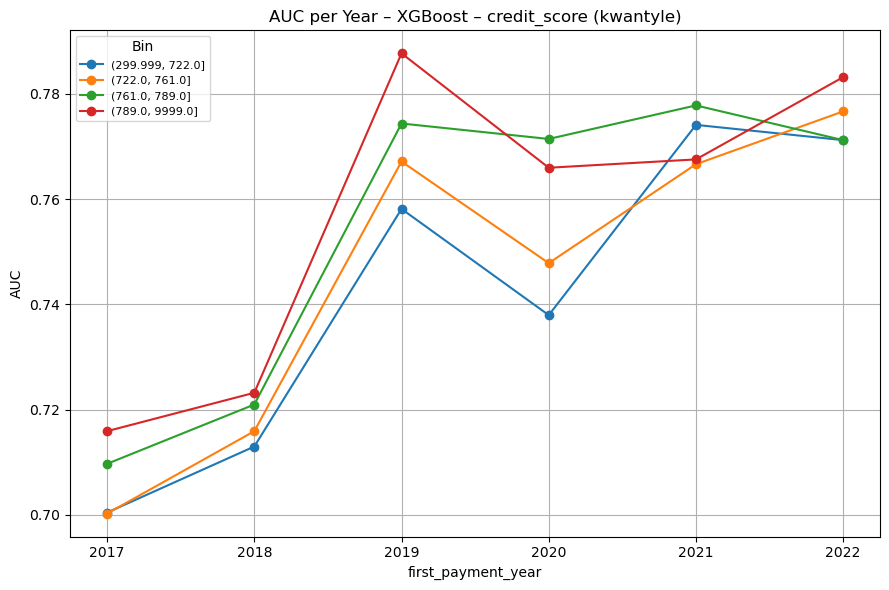

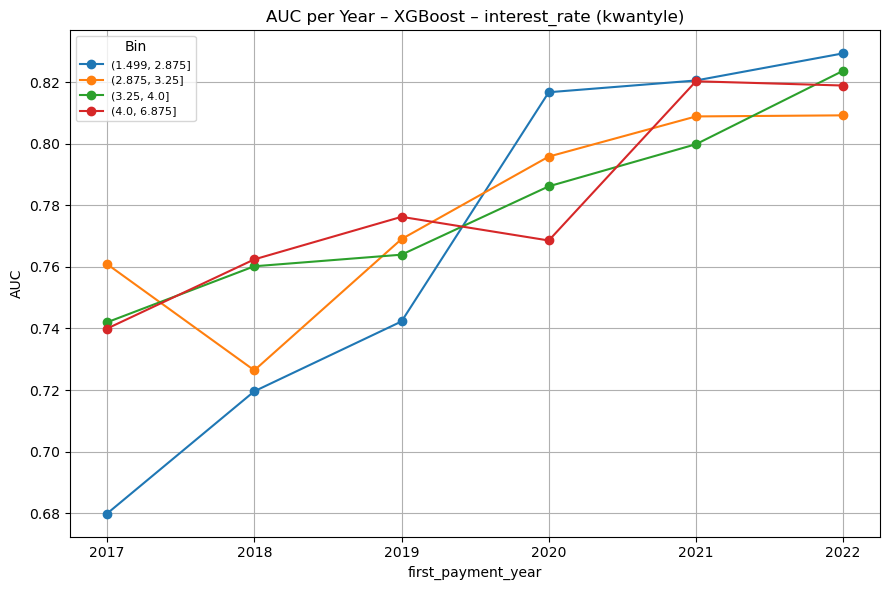

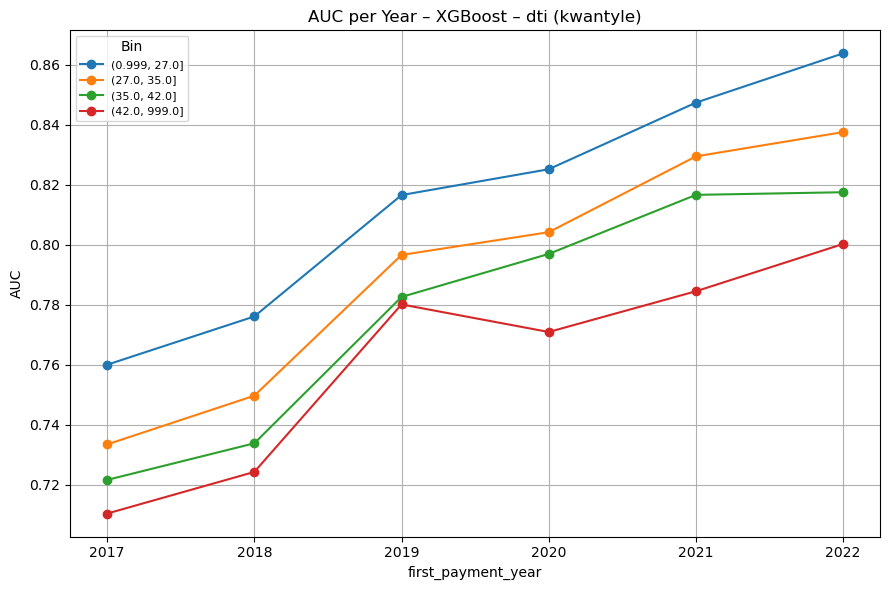

Analizy dla modelu XGBoost zostały zapisane.


In [1]:
#===========
# 4. ANALIZY
#===========
import joblib
import os
import pandas as pd
import duckdb as db
import numpy as np
import gc
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import os
import re
import warnings
import xgboost as xgb 
from xgboost import XGBClassifier
from xgboost import callback
from sklearn.model_selection import RandomizedSearchCV, StratifiedShuffleSplit
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix, roc_curve,
    precision_recall_curve, PrecisionRecallDisplay, average_precision_score
)
from sklearn.inspection import permutation_importance
from scipy.stats import uniform, randint

def cleanup(*objs):
    """Usuwa wskazane obiekty i czyści RAM"""
    for obj in objs:
        try:
            del obj
        except Exception:
            pass
    plt.close("all")
    gc.collect()

warnings.filterwarnings("ignore")

def _safe_fname(s: str) -> str:
    return "".join(ch if ch.isalnum() or ch in "-._" else "_" for ch in str(s))

# Ścieżki
data_path = ""
output_dir = os.path.join(data_path, "Wyniki_XGBoost")
os.makedirs(output_dir, exist_ok=True)

# Wczytanie modelu
model_path = os.path.join(output_dir, "xgb_model_final.pkl")
clf_best = joblib.load(model_path)
print("Model wczytany:", clf_best)

# Wczytanie testu z predykcjami
test_with_preds_path = os.path.join(output_dir, "xgb_test_with_preds.parquet")
X_test = pd.read_parquet(test_with_preds_path)

# Wczytanie feature_names
features_path = os.path.join(output_dir, "xgb_feature_names.npy")
feature_names = np.load(features_path, allow_pickle=True).tolist()

# SHAP (wczytane z plików)
shap_values = np.load(os.path.join(output_dir, "shap_values.npy"), allow_pickle=True)
shap_base   = np.load(os.path.join(output_dir, "shap_base_values.npy"), allow_pickle=True)
X_sample    = pd.read_parquet(os.path.join(output_dir, "shap_sample.parquet"))

# listy cech
top5     = pd.read_csv(os.path.join(output_dir, "shap_top5.csv")).iloc[:,0].tolist()
TOP_CONT = pd.read_csv(os.path.join(output_dir, "shap_top_cont.csv")).iloc[:,0].tolist()
TOP_CAT  = pd.read_csv(os.path.join(output_dir, "shap_top_cat.csv")).iloc[:,0].tolist()

# Wektory do analiz
y_test  = X_test["y_true"]
y_proba = X_test["y_proba"]
y_pred  = X_test["y_pred"]

print("Model wczytany:", clf_best)

#==========
# ROC Curve
fpr, tpr, _ = roc_curve(X_test["y_true"], X_test["y_proba"])
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(X_test['y_true'], X_test['y_proba']):.4f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.title("Krzywa ROC – XGBoost (test)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{output_dir}/roc_curve_xgb.png")
plt.show()
plt.close()

#=================
# Confusion matrix
sns.heatmap(confusion_matrix(X_test["y_true"], X_test["y_pred"]), annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Macierz pomyłek – XGBoost (test)")
plt.tight_layout()
plt.savefig(f"{output_dir}/confusion_matrix_xgb.png")
plt.show()

#=======================
# Precision–Recall curve
precision, recall, _ = precision_recall_curve(X_test["y_true"], X_test["y_proba"])
ap = average_precision_score(X_test["y_true"], X_test["y_proba"])
PrecisionRecallDisplay(precision=precision, recall=recall, average_precision=ap).plot()
plt.tight_layout()
plt.title("Krzywa Precision-Recall – XGBoost (test)", fontsize=14)
plt.savefig(f"{output_dir}/precision_recall_curve_xgb.png")
plt.show()

#===================================
# Histogram predykcji dla klas 0 i 1
plt.figure(figsize=(8, 5))
plt.hist(X_test.loc[X_test["y_true"] == 0, "y_proba"], bins=100,
         color='blue', alpha=0.5, density=True, label="Klasa 0")
plt.hist(X_test.loc[X_test["y_true"] == 1, "y_proba"], bins=100,
         color='red', alpha=0.5, density=True, label="Klasa 1")
plt.title("Rozkład predykcji – XGBoost (test)")
plt.xlabel("Prawdopodobieństwo defaultu")
plt.ylabel("Gęstość")
plt.legend()
plt.tight_layout()
plt.savefig(f"{output_dir}/histogram_predykcji_xgb.png")
plt.show()
plt.close()

#=====
# SHAP
shap_exp = shap.Explanation(
    values = shap_values,
    base_values = shap_base,
    data = X_sample.values,
    feature_names = X_sample.columns
)

# Bar plot
fig = plt.figure()
shap.plots.bar(shap_exp, max_display=20, show=False)
plt.title("SHAP Bar Plot – XGBoost", fontsize=14)
plt.tight_layout()
plt.savefig(f"{output_dir}/shap_bar_xgb.png")
plt.show(); plt.close(fig)

# Beeswarm plot
fig = plt.figure()
shap.plots.beeswarm(shap_exp, max_display=30, show=False)
plt.title("SHAP Beeswarm Plot – XGBoost", fontsize=14)
plt.tight_layout()
plt.savefig(f"{output_dir}/shap_beeswarm_xgb.png")
plt.show(); plt.close(fig)

# Waterfall plot
k = 5
impact = np.abs(shap_exp.values).sum(axis=1)
idx_sorted = np.argsort(impact)[::-1]
idx_keep = [int(i) for i in idx_sorted if np.isfinite(impact[int(i)]) and impact[int(i)] > 1e-8][:k]

if not idx_keep:
    print("Brak obserwacji z niezerowym wpływem – pominięcie waterfall i force.")
else:
    for rank, idx in enumerate(idx_keep, 1):
        fig = plt.figure()
        shap.plots.waterfall(shap_exp[idx], show=False)
        plt.title(f"SHAP Waterfall – obs {idx} (rank {rank})", fontsize=12)
        plt.tight_layout()
        plt.savefig(f"{output_dir}/shap_waterfall_rank{rank}_obs{idx}_xgb.png")
        plt.show(); plt.close(fig)

# Force plot
    try:
        force_obj = shap.plots.force(shap_exp[idx_keep[0]])
        shap.save_html(f"{output_dir}/shap_force_obs{idx_keep[0]}_xgb.html", force_obj)
        print(f"Zapisano force plot HTML: shap_force_obs{idx_keep[0]}_xgb.html")
    except Exception as e:
        print(f"Force plot HTML sę nie wygenerował: {e}")

#=======================
# SHAP Dependence - CONT
for feature in TOP_CONT:
    try:
        fig = plt.figure()
        shap.plots.scatter(
            shap_exp[:, feature],
            color=shap_exp[:, feature],   # kolor wg tej samej cechy
            show=False
        )
        plt.title(f"SHAP Dependence – {feature} (XGBoost)")
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, f"shap_dependence_{_safe_fname(feature)}_xgb.png"), dpi=150)
        plt.show(); plt.close(fig)
    except Exception as e:
        print(f"Dependence plot – błąd dla {feature}: {e}")

cleanup(shap_exp, X_sample)

#====================
# PDP (binned) – CONT
_X = X_test[feature_names]

for feature in TOP_CONT:
    try:
        s = pd.to_numeric(_X[feature], errors="coerce")
        if s.dropna().nunique() < 3:
            continue
        bins = pd.qcut(s, q=10, duplicates="drop")
        df_tmp = pd.DataFrame({feature: bins, "pred_proba": y_proba}).dropna()
        if df_tmp[feature].nunique() < 2:
            continue

        grouped = df_tmp.groupby(feature, observed=False)["pred_proba"].mean().reset_index()

        plt.figure(figsize=(8, 5))
        plt.plot(grouped[feature].astype(str), grouped["pred_proba"], marker="o")
        plt.title(f"PDP (binned) – {feature} – XGBoost")
        plt.xlabel(feature); plt.ylabel("Śr. prawd. defaultu")
        plt.xticks(rotation=45, ha="right"); plt.tight_layout()
        plt.savefig(os.path.join(output_dir, f"pdp_binned_{_safe_fname(feature)}_xgb.png"), dpi=150)
        plt.show(); plt.close()
    except Exception as e:
        print(f"PDP (cont) – błąd dla {feature}: {e}")

#====================
# PDP (binned) -  CAT
for feature in TOP_CAT:
    try:
        dfc = pd.DataFrame({feature: _X[feature], "pred_proba": y_proba}).dropna()
        if dfc[feature].nunique() < 2:
            continue

        grouped = dfc.groupby(feature)["pred_proba"].mean().sort_index()

        ax = grouped.plot(kind="bar", figsize=(6, 4))
        ax.set_title(f"PDP (0/1) – {feature} – XGBoost")
        ax.set_xlabel(feature); ax.set_ylabel("Śr. prawd. defaultu")

        # jeśli to typowe binarne 0/1, podpisanie odpowiednio słupków
        if set(grouped.index) <= {0, 1}:
            ax.set_xticklabels([f"{feature}=0", f"{feature}=1"], rotation=0)

        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, f"pdp_cat_{_safe_fname(feature)}_xgb.png"), dpi=150)
        plt.show(); plt.close()
    except Exception as e:
        print(f"PDP (cat) – błąd dla {feature}: {e}")

#========================
# FP/FN analiza + eksport
errors_df_full = X_test.copy()
errors_df_full["y_true"] = y_test.values
errors_df_full["y_pred"] = y_pred
errors_df_full["y_pred_proba"] = y_proba
errors_df_full["error_type"] = np.select([
    (errors_df_full["y_true"] == 0) & (errors_df_full["y_pred"] == 1),  # FP
    (errors_df_full["y_true"] == 1) & (errors_df_full["y_pred"] == 0)   # FN
], ["FP", "FN"], default="Correct")

# Tylko FP/FN do CSV
errors_df_full.loc[errors_df_full["error_type"].isin(["FP", "FN"])].to_csv(
    os.path.join(output_dir, "fp_fn_cases_xgb.csv"), index=False
)

# Tabela błędów
errors_df = pd.DataFrame({
    "y_true": y_test,
    "y_pred": y_pred,
    "y_pred_proba": y_proba
}, index=X_test.index)

if "first_payment_year" in X_test.columns:
    errors_df = errors_df.join(X_test[["first_payment_year"]])

errors_df["error_type"] = np.select(
    [
        (errors_df["y_true"] == 1) & (errors_df["y_pred"] == 0),  # FN
        (errors_df["y_true"] == 0) & (errors_df["y_pred"] == 1)   # FP
    ],
    ["FN", "FP"],
    default="OK"
)
errors_df = errors_df.rename(columns={"y_pred_proba": "y_proba"})

# Zapis
errors_df.to_csv(os.path.join(output_dir, "errors_fp_fn_xgb.csv"), index=True)

#=========================
# Boxploty FP vs FN - CONT
plot_df = errors_df.loc[errors_df["error_type"].isin(["FP", "FN"])]

for var in TOP_CONT:
    if var not in X_test.columns:
        continue

    df_plot = pd.concat([plot_df[["error_type"]], X_test[[var]]], axis=1)

    nunq = df_plot[var].dropna().nunique()
    if nunq < 3:
        print(f"Pominięcie {var} – za mało unikalnych wartości ({nunq}).")
        continue

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.boxplot(data=df_plot, x="error_type", y=var, order=["FN", "FP"], ax=ax)
    ax.set_title(f"Boxplot {var} – FP vs FN (XGBoost)")
    ax.set_xlabel("Typ błędu"); ax.set_ylabel(var)
    fig.tight_layout()
    fig.savefig(os.path.join(output_dir, f"boxplot_fpfn_{_safe_fname(var)}_xgb.png"), dpi=150)
    plt.show(); plt.close(fig)

#===
#PSI
def calculate_psi(expected, actual, bins=10, method="proportion"):
    """
    PSI między rozkładami expected i actual.
    method="proportion"
    method="density" 
    """
    e = pd.to_numeric(pd.Series(expected), errors="coerce").dropna().values
    a = pd.to_numeric(pd.Series(actual),   errors="coerce").dropna().values
    if e.size == 0 or a.size == 0:
        return np.nan

# Wspólne krawędzie koszyków
    if method == "density":
        e_perc, edges = np.histogram(e, bins=bins, range=(0, 1), density=True)
        a_perc, _     = np.histogram(a, bins=edges, density=True)
    else:
        e_cnt, edges = np.histogram(e, bins=bins, range=(0, 1))
        a_cnt, _     = np.histogram(a, bins=edges)
        e_sum = max(e_cnt.sum(), 1)
        a_sum = max(a_cnt.sum(), 1)
        e_perc = e_cnt / e_sum
        a_perc = a_cnt / a_sum

    e_perc = e_perc + 1e-6
    a_perc = a_perc + 1e-6
    return float(np.sum((e_perc - a_perc) * np.log(e_perc / a_perc)))

# Wykres
errors_df["first_payment_year"] = errors_df["first_payment_year"].astype("Int64")

base_year = 2017
base_scores = errors_df.loc[errors_df["first_payment_year"] == base_year, "y_proba"]

years = (
    errors_df["first_payment_year"]
    .dropna().astype(int).sort_values().unique().tolist()
)

psi_vals = []
for year in years:
    if year == base_year:
        continue
    actual = errors_df.loc[errors_df["first_payment_year"] == year, "y_proba"]
    if len(base_scores) and len(actual):
        psi_vals.append((year, calculate_psi(base_scores, actual, bins=10, method="proportion")))

psi_df = pd.DataFrame(psi_vals, columns=["Rok", "PSI"]).sort_values("Rok")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(psi_df["Rok"], psi_df["PSI"], marker="o")
ax.set_xticks(psi_df["Rok"])
ax.set_xticklabels(psi_df["Rok"].astype(str))
ax.set_xlabel("first_payment_year")
ax.set_ylabel("PSI")
ax.set_title("PSI vs 2017 – XGBoost")
ax.grid(True)
plt.tight_layout()
plt.savefig(f"{output_dir}/psi_xgb.png")
plt.show()

psi_df.to_csv(f"{output_dir}/psi_xgb.csv", index=False)

cleanup(psi_df)

#=======================
# Permutation Importance
X_test_small = X_test[feature_names].sample(n=1000, random_state=42)
y_test_small = y_test.loc[X_test_small.index]

perm_result = permutation_importance(
    clf_best,
    X_test_small,
    y_test_small,
    n_repeats=2,
    scoring='roc_auc',
    random_state=42
)

perm_df = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
}).sort_values(by="importance_mean", ascending=False)

# Zapis do CSV
perm_df.to_csv(f"{output_dir}/permutation_importance_full.csv", index=False)
perm_df.head(10).to_csv(f"{output_dir}/permutation_importance_top10.csv", index=False)

# Bar plot dla top 10
plt.figure(figsize=(10, 6))
sns.barplot(
    x="importance_mean",
    y="feature",
    data=perm_df.head(10)
)
plt.title("Permutation Importance (top 10) – XGBoost")
plt.xlabel("Mean decrease in AUC")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(f"{output_dir}/permutation_importance_top10_plot.png")
plt.show()

#=====================
# Feature Perturbation
print("Perturbacja – TOP_CONT (XGBoost)")

PERTURB_TOP_N   = 5
PERCENT_DELTAS  = np.array([-0.20, -0.10, -0.05, 0.0, 0.05, 0.10, 0.20])
STD_STEPS       = np.array([-1.0, -0.5, -0.25, 0.0, 0.25, 0.5, 1.0])
SAMPLE_ROWS     = 200
SHOW_N_LINES    = 50

FEATURES_FOR_PERTURB = TOP_CONT[:PERTURB_TOP_N]
print("Perturbacja — cechy:", FEATURES_FOR_PERTURB)

base_idx = X_test.index[:min(SAMPLE_ROWS, len(X_test))]
X_base_all = X_test.loc[base_idx, feature_names].copy()

perturb_summary_rows = []

for var in FEATURES_FOR_PERTURB:
    try:
        if var not in X_base_all.columns:
            continue
        x = X_base_all[var].dropna()
        if x.empty:
            print(f"Pominięcie {var} — same NaN.")
            continue

# Wybór trybu perturbacji: procentowy czy addytywny (±σ)
        use_multiplicative = (x.min() > 0) and (np.nanmedian(x) > 1e-12)

        preds_grid, labels = [], []
        if use_multiplicative:
# Perturbacje procentowe
            for d in PERCENT_DELTAS:
                Xp = X_base_all.copy()
                Xp.loc[x.index, var] = x * (1.0 + d)
                y_pred_tmp = clf_best.predict_proba(Xp)[:, 1]
                preds_grid.append(y_pred_tmp)
                labels.append(f"{int(d*100)}%")
        else:
# Perturbacje addytywne względem odchylenia standardowego
            std = float(np.nanstd(x))
            if not np.isfinite(std) or std < 1e-12:
                print(f"Pominięcie {var} — brak sensownego std do perturbacji addytywnej.")
                continue
            for s in STD_STEPS:
                Xp = X_base_all.copy()
                Xp.loc[x.index, var] = x + s * std
                # y_pred_tmp = clf_best.predict(xgb.DMatrix(Xp))  
                y_pred_tmp = clf_best.predict_proba(Xp)[:, 1]
                preds_grid.append(y_pred_tmp)
                labels.append(f"{s:+.2f}σ")

# Wykres
        fig, ax = plt.subplots(figsize=(8, 6))
        show_n = min(SHOW_N_LINES, len(X_base_all))
        for i in range(show_n):
            ax.plot(range(len(labels)), [preds_grid[k][i] for k in range(len(labels))], alpha=0.25)
        mean_curve = np.array([np.mean(pg) for pg in preds_grid])
        ax.plot(range(len(labels)), mean_curve, linewidth=3, label="Średnia")
        ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels)
        ax.set_title(f"Perturbacja cechy – {var} (XGBoost)")
        ax.set_xlabel("Wielkość perturbacji"); ax.set_ylabel("Prawdopodobieństwo defaultu")
        ax.legend(); ax.grid(True); fig.tight_layout()
        fig.savefig(os.path.join(output_dir, f"feature_perturbation_{_safe_fname(var)}_xgb.png"), dpi=150)
        plt.show(); plt.close(fig)

# Podsumowanie dla ±10%
        key = { -10: None, 0: None, +10: None }
        for pct in key.keys():
            try:
                if use_multiplicative:
                    idx = list(PERCENT_DELTAS).index(pct/100.0)
                else:
                    idx = None
                key[pct] = float(mean_curve[idx]) if idx is not None else np.nan
            except Exception:
                key[pct] = np.nan

        perturb_summary_rows.append({
            "feature": var,
            "mean_pred_-10%": key[-10],
            "mean_pred_0%":   key[0],
            "mean_pred_+10%": key[+10],
            "delta(+10% - 0%)": (key[+10] - key[0]) if all(pd.notna([key[+10], key[0]])) else np.nan,
            "delta(0% - -10%)": (key[0] - key[-10]) if all(pd.notna([key[0], key[-10]])) else np.nan
        })
    except Exception as e:
        print(f"Perturbacja — błąd dla {var}: {e}")

if perturb_summary_rows:
    pd.DataFrame(perturb_summary_rows).to_csv(
        os.path.join(output_dir, "feature_perturbation_summary_xgb.csv"),
        index=False
    )
    print("Zapisano: feature_perturbation_summary_xgb.csv")
else:
    print("Brak wyników perturbacji.")

cleanup(preds_grid, X_base_all)

#==========================================
# Miary natywne XGBoost: feature importance
booster = clf_best.get_booster()
importance_types = ['weight', 'gain', 'cover', 'total_gain', 'total_cover']
feature_map = {f"f{idx}": name for idx, name in enumerate(feature_names)}

for imp_type in importance_types:
    importance_raw = booster.get_score(importance_type=imp_type)
    importance_mapped = {feature_map.get(k, k): v for k, v in importance_raw.items()}

    imp_df = pd.DataFrame.from_dict(importance_mapped, orient='index', columns=[imp_type])
    imp_df.sort_values(by=imp_type, ascending=False, inplace=True)
    imp_df.to_csv(f"{output_dir}/xgb_importance_{imp_type}_xgb.csv")

    plt.figure(figsize=(8, 6))
    imp_df.head(20).plot(kind='barh', legend=False)
    plt.title(f"XGBoost Importance – {imp_type}")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig(f"{output_dir}/xgb_importance_{imp_type}_xgb.png")
    plt.show()
    plt.close()

#====
# CSI
print("CSI (Top5 CONT): bazowy rok vs bieżące dane – XGBoost")

base_year = 2017
X_test["first_payment_year"] = pd.to_numeric(X_test["first_payment_year"], errors="coerce").astype("Int64")

FEATURES_FOR_CSI = TOP_CONT[:5] if "TOP_CONT" in globals() else []
if not FEATURES_FOR_CSI:
    _X = X_test[feature_names]
    def _is_dummy01(s: pd.Series) -> bool:
        u = pd.Series(s.dropna().unique())
        return (len(u) > 0) and u.isin([0, 1]).all()
    def _is_name_excluded(name: str) -> bool:
        n = str(name).lower()
        _EXCLUDE_NAME_TOKENS = ["msa","zip","postal","code","id","year","month","date","day","days_since","number_of_borrowers"]
        _EXCLUDE_EXACT = {"first_payment_year"}
        if n in _EXCLUDE_EXACT: return True
        return any(tok in n for tok in _EXCLUDE_NAME_TOKENS)
    FEATURES_FOR_CSI = [
        c for c in top5 if (c in _X.columns)
        and not _is_name_excluded(c)
        and pd.api.types.is_numeric_dtype(_X[c])
        and not _is_dummy01(_X[c])
        and _X[c].nunique(dropna=True) >= 3
    ]

# Helpery
def _safe_fname(s: str) -> str:
    return re.sub(r"[^A-Za-z0-9_.\-+=]+", "_", str(s))

def _quantile_edges(arr, max_bins=10, min_bins=3):
    s = pd.to_numeric(pd.Series(arr), errors="coerce").dropna().values
    if s.size < 2: return None
    for b in range(max_bins, min_bins - 1, -1):
        edges = np.unique(np.quantile(s, np.linspace(0, 1, b + 1)))
        if edges.size >= (min_bins + 1): return edges
    return None

def _csi_from_edges(base_vals, cur_vals, edges):
    b = pd.to_numeric(pd.Series(base_vals), errors="coerce").dropna().values
    c = pd.to_numeric(pd.Series(cur_vals),  errors="coerce").dropna().values
    if b.size == 0 or c.size == 0: return np.nan
    b_cnt, _ = np.histogram(b, bins=edges)
    c_cnt, _ = np.histogram(c, bins=edges)
    if b_cnt.sum() == 0 or c_cnt.sum() == 0: return np.nan
    b_p = b_cnt / b_cnt.sum() + 1e-6
    c_p = c_cnt / c_cnt.sum() + 1e-6
    return float(np.sum((b_p - c_p) * np.log(b_p / c_p)))

rows = []
min_n = 100

for feat in FEATURES_FOR_CSI:
    if feat not in X_test.columns or feat == "first_payment_year":
        continue

    df = X_test[["first_payment_year", feat]].dropna().copy()
    if df.empty or df[feat].nunique() < 3:
        print(f"CSI: pominięcie {feat} – zbyt mało unikalnych wartości.")
        continue

    counts = df["first_payment_year"].value_counts()
    by = base_year if (base_year in counts.index and counts.loc[base_year] >= min_n) else int(counts.idxmax())

    base_vals = df.loc[df["first_payment_year"] == by, feat].values
    cur_vals  = df.loc[df["first_payment_year"] != by, feat].values
    if base_vals.size < min_n or cur_vals.size < min_n:
        print(f"CSI: pominięcie {feat} – za mało danych (base={base_vals.size}, curr={cur_vals.size}).")
        continue

    edges = _quantile_edges(np.concatenate([base_vals, cur_vals]), max_bins=10, min_bins=3)
    if edges is None:
        print(f"CSI: pominięcie {feat} – nie udało się wyznaczyć sensownych binów.")
        continue

    csi_val = _csi_from_edges(base_vals, cur_vals, edges)
    rows.append({"feature": feat, "base_year": by, "n_base": base_vals.size, "n_curr": cur_vals.size, "CSI": csi_val})

# Wykres rozkładów
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.histplot(pd.to_numeric(base_vals), label=f"Rok {by}", kde=True, stat="density", bins=30, ax=ax)
    sns.histplot(pd.to_numeric(cur_vals),  label="Bieżące dane", kde=True, stat="density", bins=30, ax=ax)
    ax.set_title(f"CSI vs {by} – XGBoost ({feat})")
    ax.set_xlabel(feat); ax.set_ylabel("Gęstość"); ax.legend()
    fig.tight_layout()
    plt.savefig(f"{output_dir}/csi_distribution_{_safe_fname(feat)}_xgb.png")
    plt.show(); plt.close(fig)

# Zapis zbiorczy
if rows:
    csi_df = pd.DataFrame(rows).sort_values(["feature"])
    csi_df.to_csv(f"{output_dir}/csi_xgb_top5_summary.csv", index=False)
    print("CSI zapisane do:", f"{output_dir}/csi_xgb_top5_summary.csv")
else:
    print("CSI: brak wyników dla Top-5 CONT (XGBoost).")

cleanup()
#=============
# AUC per year
print("AUC per year – TOP_CONT i TOP_CAT (XGBoost)")

df_base = X_test.copy()
df_base["y_proba"] = y_proba
df_base["y_true"]  = y_test.values
df_base["first_payment_year"] = pd.to_numeric(df_base["first_payment_year"], errors="coerce").astype("Int64")

# TOP_CONT (kwantyle)
nbins = 4
min_group = 30

for feat in TOP_CONT:
    df = df_base[["first_payment_year", feat, "y_true", "y_proba"]].dropna().copy()
    if df[feat].nunique() < 3:
        print(f"Pominięcie {feat} – za mało unikalnych do kwantyli.")
        continue
    try:
        df["bin"] = pd.qcut(df[feat], q=nbins, duplicates="drop")
    except Exception:
        print(f"Pominięcie {feat} – qcut nieudany.")
        continue

    rows = []
    for (yr, b), g in df.groupby(["first_payment_year", "bin"], observed=False):
        if pd.isna(yr) or len(g) < min_group or g["y_true"].nunique() < 2:
            continue
        auc = roc_auc_score(g["y_true"], g["y_proba"])
        rows.append({"year": int(yr), "bin": str(b), "AUC": auc})

    if not rows:
        continue

    res = pd.DataFrame(rows).sort_values(["year", "bin"])
    safe = re.sub(r"[^A-Za-z0-9_\-+=]+", "_", feat)
    res.to_csv(f"{output_dir}/auc_per_year_by_bin_{safe}_xgb.csv", index=False)

    pivot = res.pivot(index="year", columns="bin", values="AUC").sort_index()
    plt.figure(figsize=(9, 6))
    for col in pivot.columns:
        plt.plot(pivot.index, pivot[col], marker="o", label=str(col))
    plt.title(f"AUC per Year – XGBoost – {feat} (kwantyle)")
    plt.xlabel("first_payment_year"); plt.ylabel("AUC")
    plt.grid(True); plt.legend(title="Bin", fontsize=8)
    plt.tight_layout()
    plt.savefig(f"{output_dir}/auc_per_year_by_bin_{safe}.png")
    plt.show()

cleanup()

print("Analizy dla modelu XGBoost zostały zapisane.")